In [1]:
#Import Libs and setup plotting settings
import os.path
import xarray as xr
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

SMALL_SIZE = 6
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
#Functions that will be used for postprocessing
class apce_data_struct:
    def __init__(self, t, ds_t, icemass, h2omass, numparts):
        self.t = t
        self.ds_t = ds_t
        self.icemass = icemass
        self.h2omass = h2omass
        self.numparts = numparts
    
def read_apcemm_data(directory):
    t_mins = []
    ds_t = []
    ice_mass = []
    total_h2o_mass = []
    num_particles = []

    for file in sorted(os.listdir(directory)):
        if(file.startswith('ts_aerosol') and file.endswith('.nc')):
            file_path = os.path.join(directory,file)
            ds = xr.open_dataset(file_path, engine = "netcdf4", decode_times = False)
            ds_t.append(ds)
            tokens = file_path.split('.')
            mins = int(tokens[-2][-2:])
            hrs = int(tokens[-2][-4:-2])
            t_mins.append(hrs*60 + mins)

            ice_mass.append(ds["Ice Mass"])
            num_particles.append(ds["Number Ice Particles"])
            dx = abs(ds["x"][-1] - ds["x"][0])/len(ds["x"])
            dy = abs(ds["y"][-1] - ds["y"][0])/len(ds["y"])
            
            h2o_mass = np.sum(ds["H2O"]) * 1e6 / 6.022e23 * 0.018 * dx*dy + ds["Ice Mass"]
            total_h2o_mass.append(h2o_mass.values)
    return apce_data_struct(t_mins, ds_t, ice_mass, total_h2o_mass, num_particles)

def removeLow(arr, cutoff = 1e-3):
    func = lambda x: (x > cutoff) * x
    vfunc = np.vectorize(func)
    return vfunc(arr)

In [3]:
apce_data1 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_1')
t1 = apce_data1.t
ds_t1 = apce_data1.ds_t
ice_mass1 = apce_data1.icemass
total_h2o_mass1 = apce_data1.h2omass

apce_data2 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_2')
t2 = apce_data2.t
ds_t2 = apce_data2.ds_t
ice_mass2 = apce_data2.icemass
total_h2o_mass2 = apce_data2.h2omass

apce_data3 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_3')
t3 = apce_data3.t
ds_t3 = apce_data3.ds_t
ice_mass3 = apce_data3.icemass
total_h2o_mass3 = apce_data3.h2omass

apce_data4 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_4')
t4 = apce_data4.t
ds_t4 = apce_data4.ds_t
ice_mass4 = apce_data4.icemass
total_h2o_mass4 = apce_data4.h2omass

apce_data5 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_5')
t5 = apce_data5.t
ds_t5 = apce_data5.ds_t
ice_mass5 = apce_data5.icemass
total_h2o_mass5 = apce_data5.h2omass

apce_data6 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_6')
t6 = apce_data6.t
ds_t6 = apce_data6.ds_t
ice_mass6 = apce_data6.icemass
total_h2o_mass6 = apce_data6.h2omass

apce_data7 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_7')
t7 = apce_data7.t
ds_t7 = apce_data7.ds_t
ice_mass7 = apce_data7.icemass
total_h2o_mass7 = apce_data7.h2omass

apce_data8 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_8')
t8 = apce_data8.t
ds_t8 = apce_data8.ds_t
ice_mass8 = apce_data8.icemass
total_h2o_mass8 = apce_data8.h2omass

apce_data9 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_9')
t9 = apce_data9.t
ds_t9 = apce_data9.ds_t
ice_mass9 = apce_data9.icemass
total_h2o_mass9 = apce_data9.h2omass

apce_data10 = read_apcemm_data('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/outputs/test_1_run_10')
t10 = apce_data10.t
ds_t10 = apce_data10.ds_t
ice_mass10 = apce_data10.icemass
total_h2o_mass10 = apce_data10.h2omass

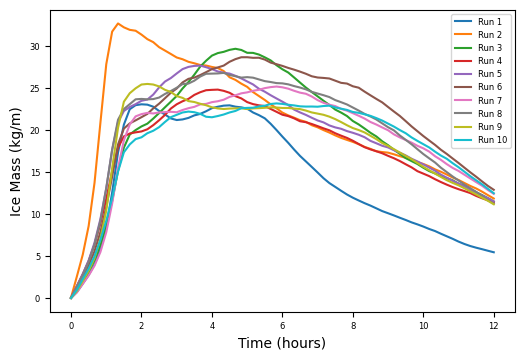

In [5]:
# Example of plotting variables that are a function of time
fig, axes = plt.subplots(dpi=100)
t_s = [i * 60 for i in t1]

# Plot ice_mass for each dataset
for i, ice_mass in enumerate([ice_mass1, ice_mass2, ice_mass3, ice_mass4, ice_mass5, ice_mass6, ice_mass7, ice_mass8, ice_mass9, ice_mass10], start=1):
    axes.plot([i / 3600 for i in t_s], ice_mass, label=f'Run {i}')

axes.set_xlabel("Time (hours)")
axes.set_ylabel("Ice Mass (kg/m)")
plt.legend()
plt.show()

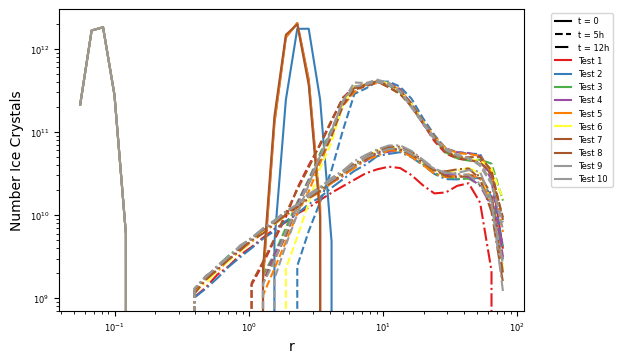

In [6]:
# Visualizing the evolution of the particle radius distribution over time for tests 1-10
fig, axes = plt.subplots(dpi=100)

# Define line styles for different times
line_styles = ['-', '--', '-.', ':']
time_labels = ['t = 0', 't = 5h', 't = 12h']

# Define colors for different tests using the Set1 colormap
colors = plt.cm.Set1(np.linspace(0, 1, 10))

# Plot for each test
for i, (ds_t, color) in enumerate(zip([ds_t1, ds_t2, ds_t3, ds_t4, ds_t5, ds_t6, ds_t7, ds_t8, ds_t9, ds_t10], colors), start=1):
    axes.plot(ds_t[0]['r'] * 1e6, removeLow(ds_t[0]["Overall size distribution"], cutoff=1e9), linestyle=line_styles[0], color=color)
    axes.plot(ds_t[30]['r'] * 1e6, removeLow(ds_t[30]["Overall size distribution"], cutoff=1e9), linestyle=line_styles[1], color=color)
    axes.plot(ds_t[72]['r'] * 1e6, removeLow(ds_t[72]["Overall size distribution"], cutoff=1e9), linestyle=line_styles[2], color=color)

# Create custom legend for time labels
for style, label in zip(line_styles, time_labels):
    axes.plot([], [], linestyle=style, color='black', label=label)

# Create custom legend for test numbers
for i, color in enumerate(colors, start=1):
    axes.plot([], [], color=color, label=f'Test {i}')

axes.set_xlabel('r')
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_ylabel('Number Ice Crystals')

# Move the legend off of the plot and to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

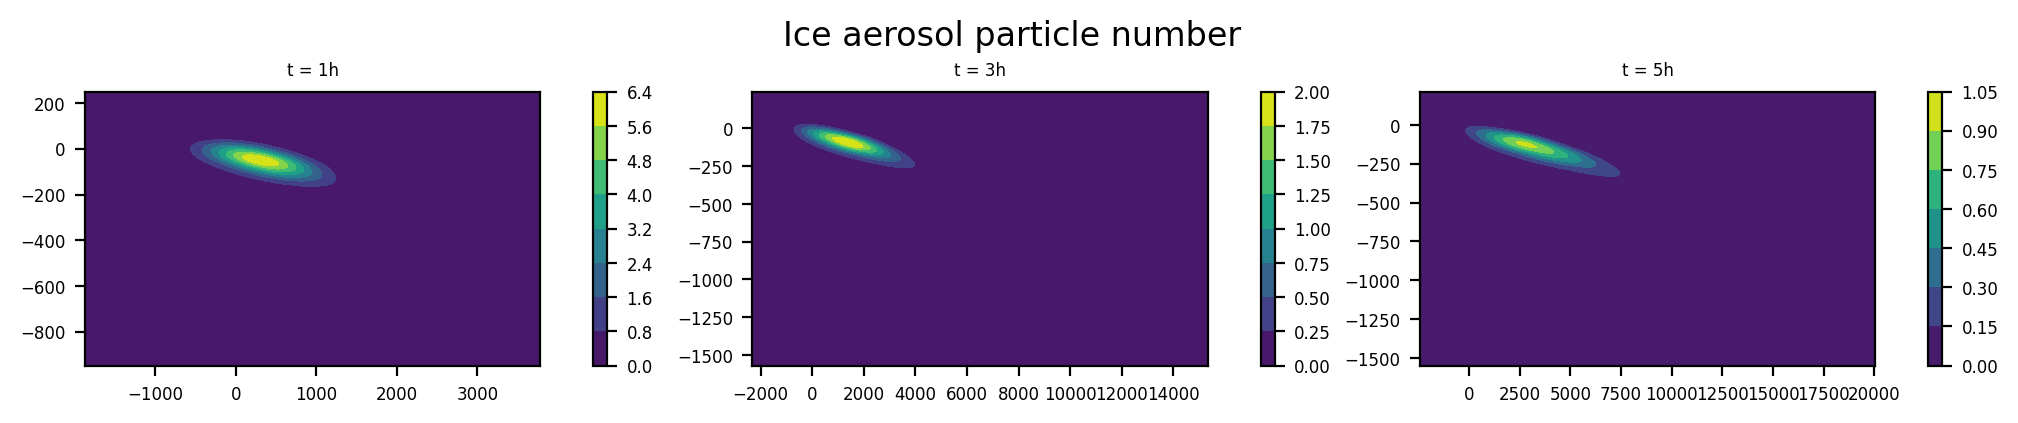

In [7]:
#Looking at some 2D contours over time (e.g. Ice aerosol particle number)
fig, ((ax11, ax12, ax13)) = plt.subplots(nrows = 1, ncols = 3, dpi=200, figsize=[10, 2])
fig.suptitle("Ice aerosol particle number")

ds_t_1h = ds_t[6]
X_map1h, Y_map1h = np.meshgrid(ds_t_1h["x"], ds_t_1h["y"])
map1h = ax11.contourf(X_map1h, Y_map1h, ds_t_1h['Ice aerosol particle number'])
ax11.set_title('t = 1h')
plt.colorbar(map1h, ax = ax11,fraction=0.046, pad=0.1)


ds_t_3h = ds_t[18]
X_map3h, Y_map3h = np.meshgrid(ds_t_3h["x"], ds_t_3h["y"])
map3h=ax12.contourf(X_map3h, Y_map3h, ds_t_3h['Ice aerosol particle number'])
ax12.set_title('t = 3h')
plt.colorbar(map3h, ax = ax12,fraction=0.046, pad=0.1)


ds_t_5h = ds_t[30]
X_map5h, Y_map5h = np.meshgrid(ds_t_5h["x"], ds_t_5h["y"])
map5h=ax13.contourf(X_map5h, Y_map5h, ds_t_5h['Ice aerosol particle number'])
ax13.set_title('t = 5h')
plt.colorbar(map5h, ax = ax13,fraction=0.046, pad=0.1)


fig.tight_layout(pad=0.3)

plt.show()

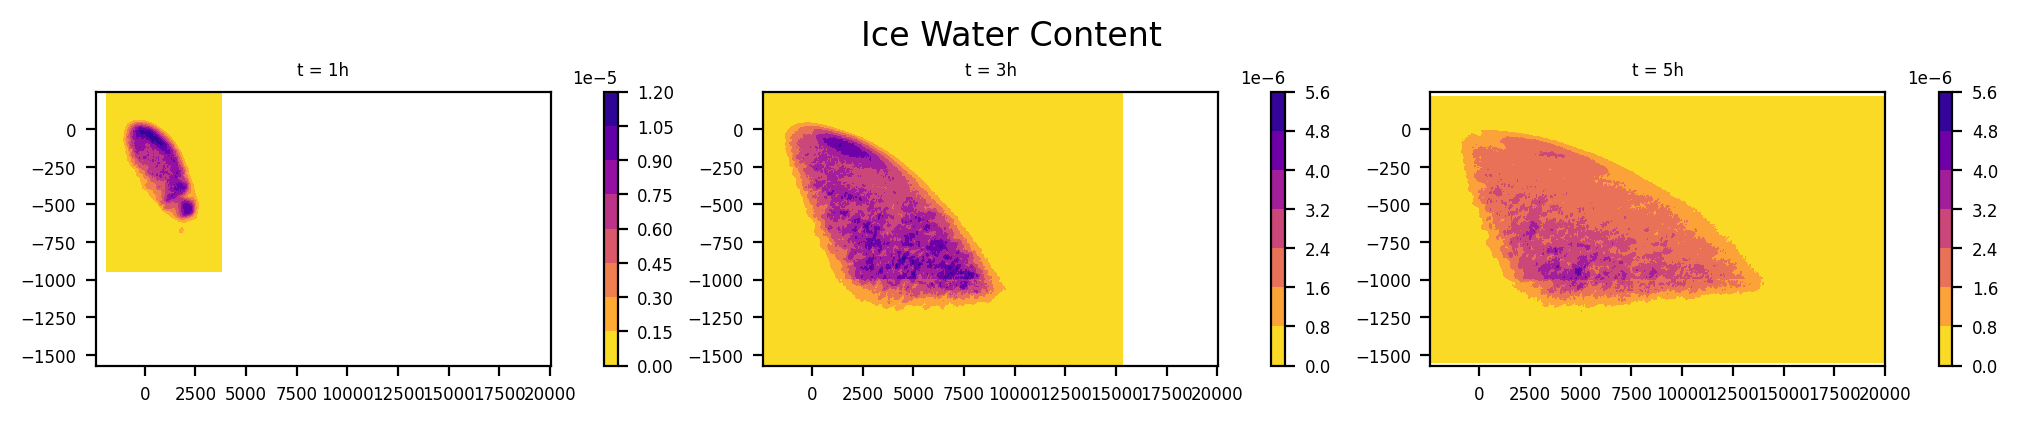

In [8]:
# Looking at a different 2D contour, IWC over time. Notice the contrast in ice particles vs ice mass distribution.
fig, ((ax11, ax12, ax13)) = plt.subplots(nrows=1, ncols=3, dpi=200, figsize=[10, 2])
fig.suptitle("Ice Water Content")

# Determine the common x and y limits
x_min = min(ds_t_1h["x"].min(), ds_t_3h["x"].min(), ds_t_5h["x"].min())
x_max = max(ds_t_1h["x"].max(), ds_t_3h["x"].max(), ds_t_5h["x"].max())
y_min = min(ds_t_1h["y"].min(), ds_t_3h["y"].min(), ds_t_5h["y"].min())
y_max = max(ds_t_1h["y"].max(), ds_t_3h["y"].max(), ds_t_5h["y"].max())

ds_t_1h = ds_t[6]
X_map1h, Y_map1h = np.meshgrid(ds_t_1h["x"], ds_t_1h["y"])
map1h = ax11.contourf(X_map1h, Y_map1h, ds_t_1h['IWC'], cmap='plasma_r')
ax11.set_title('t = 1h')
ax11.set_xlim(x_min, x_max)
ax11.set_ylim(y_min, y_max)
plt.colorbar(map1h, ax=ax11, fraction=0.046, pad=0.1)

ds_t_3h = ds_t[18]
X_map3h, Y_map3h = np.meshgrid(ds_t_3h["x"], ds_t_3h["y"])
map3h = ax12.contourf(X_map3h, Y_map3h, ds_t_3h['IWC'], cmap='plasma_r')
ax12.set_title('t = 3h')
ax12.set_xlim(x_min, x_max)
ax12.set_ylim(y_min, y_max)
plt.colorbar(map3h, ax=ax12, fraction=0.046, pad=0.1)

ds_t_5h = ds_t[30]
X_map5h, Y_map5h = np.meshgrid(ds_t_5h["x"], ds_t_5h["y"])
map5h = ax13.contourf(X_map5h, Y_map5h, ds_t_5h['IWC'], cmap='plasma_r')
ax13.set_title('t = 5h')
ax13.set_xlim(x_min, x_max)
ax13.set_ylim(y_min, y_max)
plt.colorbar(map5h, ax=ax13, fraction=0.046, pad=0.1)

fig.tight_layout(pad=0.3)
plt.show()
# Filter out the data points where x > 20000
for ax in [ax11, ax12, ax13]:
    ax.set_xlim(x_min, 20000)

plt.show()

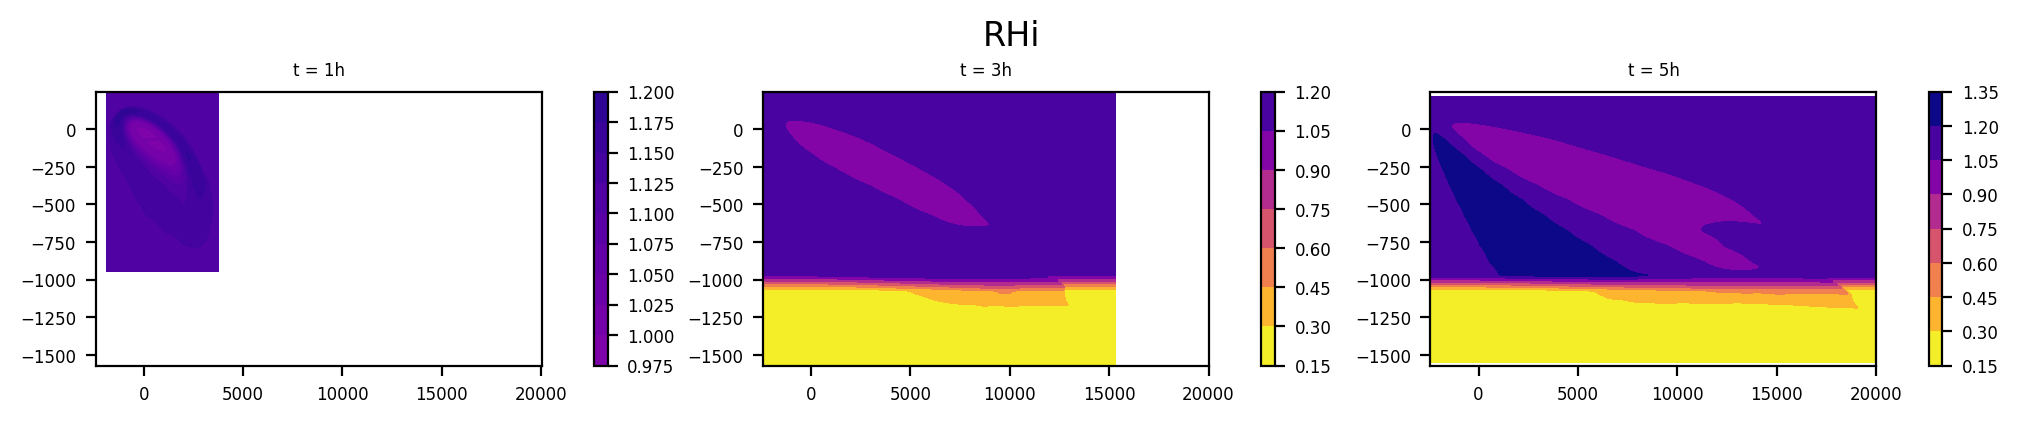

In [9]:
# To better understand this sharp cutoff at around Y = -600, we can also look at the RHi Plots, and see a discontinuity from supersaturation to subsaturation:
# Phenomena such as seeing spikes in supersaturation near the discontinuity due to instantaneous ice melting are also visible.
fig, ((ax11, ax12, ax13)) = plt.subplots(nrows=1, ncols=3, dpi=200, figsize=[10, 2])
fig.suptitle("RHi")

# Determine the common color scale limits
vmin = min(ds_t[6]['RHi'].min(), ds_t[18]['RHi'].min(), ds_t[30]['RHi'].min())
vmax = max(ds_t[6]['RHi'].max(), ds_t[18]['RHi'].max(), ds_t[30]['RHi'].max())

ds_t_1h = ds_t[6]
X_map1h, Y_map1h = np.meshgrid(ds_t_1h["x"], ds_t_1h["y"])
map1h = ax11.contourf(X_map1h, Y_map1h, ds_t_1h['RHi'], vmin=vmin, vmax=vmax, cmap='plasma_r')
ax11.set_title('t = 1h')
ax11.set_xlim(x_min, x_max)
ax11.set_ylim(y_min, y_max)
plt.colorbar(map1h, ax=ax11, fraction=0.046, pad=0.1)

ds_t_3h = ds_t[18]
X_map3h, Y_map3h = np.meshgrid(ds_t_3h["x"], ds_t_3h["y"])
map3h = ax12.contourf(X_map3h, Y_map3h, ds_t_3h['RHi'], vmin=vmin, vmax=vmax, cmap='plasma_r')
ax12.set_title('t = 3h')
ax12.set_xlim(x_min, x_max)
ax12.set_ylim(y_min, y_max)
plt.colorbar(map3h, ax=ax12, fraction=0.046, pad=0.1)

ds_t_5h = ds_t[30]
X_map5h, Y_map5h = np.meshgrid(ds_t_5h["x"], ds_t_5h["y"])
map5h = ax13.contourf(X_map5h, Y_map5h, ds_t_5h['RHi'], vmin=vmin, vmax=vmax, cmap='plasma_r')
ax13.set_title('t = 5h')
ax13.set_xlim(x_min, x_max)
ax13.set_ylim(y_min, y_max)
plt.colorbar(map5h, ax=ax13, fraction=0.046, pad=0.1)

fig.tight_layout(pad=0.3)
plt.show()

# Filter out the data points where x > 20000
for ax in [ax11, ax12, ax13]:
    ax.set_xlim(x_min, 20000)

plt.show()